In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Check that we have GPU in our setup
import torch
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [3]:
# Install dependencies for roboflow dataset
!pip install roboflow torch torchvision --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [4]:
from roboflow import Roboflow

# Import the basketball dataset, already pre-split into train-valid-test split
rf = Roboflow(api_key="r2FzjGVV2341qn8vpv2p")
project = rf.workspace("eagle-eye").project("basketball-1zhpe")
dataset = project.version(1).download("voc")   # VOC format = XML bounding boxes, works natively with SSD

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Basketball-1 in voc:: 100%|██████████| 5203/5203 [00:00<00:00, 10681.09it/s]


In [5]:
import os

# Find the actual dataset location
print("Dataset location:", dataset.location)
print()

# Go through the folder structure to see what's there to make sure we have right labels for everything
for root, dirs, files in os.walk(dataset.location):
    level = root.replace(dataset.location, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # only show files 2 levels deep
        for f in files[:3]:  # show first 3 files as sample
            print(f"  {indent}{f}")

Dataset location: /kaggle/working/Basketball-1

Basketball-1/
  README.dataset.txt
  README.roboflow.txt
  test/
    W62IM8YZS58Z_jpg.rf.a0fbb34f846926a0ad575d0ebda4e214.xml
    n02802426_3282_JPEG_jpg.rf.75b7863b177fb100c7b67b7f08b10269.jpg
    NMIYIALB7ZSI_jpg.rf.1880e431d22e152b1e8b194ad8de9ea7.jpg
  valid/
    YEMPGOJUR7PB_jpg.rf.1ffd83646137af3d6587101292a8671c.xml
    PZM4CVX149GV_jpg.rf.ca6be8792250db0cda4871f6ea74c8e8.xml
    KMK5L6FR5XBI_jpg.rf.6e669640eb754af9765961ed5b6be016.jpg
  train/
    FOKTD0L4E2LY_jpg.rf.3f21096fca77ed812ce6ff9171e9e12e.jpg
    basketball_845_jpg.rf.e1cb64ee79631b021c78220c2993b112.jpg
    basketball_174_jpg.rf.ba5c08de0de62d66e335d8243142060a.jpg


In [6]:
import os
import glob
import torch
import xml.etree.ElementTree as ET
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Load the dataset
dataset_path = "/kaggle/working/Basketball-1"
CLASS_MAP = {"basketball": 0, "rim": 1, "sports ball": 2}
IMG_SIZE = 300

# Verify the counts in the dataset
for split in ["train", "valid", "test"]:
    imgs = glob.glob(f"{dataset_path}/{split}/*.jpg")
    xmls = glob.glob(f"{dataset_path}/{split}/*.xml")
    print(f"{split}: {len(imgs)} images, {len(xmls)} labels")

train: 1997 images, 1997 labels
valid: 130 images, 130 labels
test: 472 images, 472 labels


In [7]:
# Batch size - optimized
BATCH_SIZE = 16

# CLASS MAP: 0 = background
CLASS_MAP = {"basketball": 1, "rim": 2, "sports ball": 3}
NUM_CLASSES = 4  # background + 3

# dataset class, using pixel coordinates, not normalized 
class BasketballDataset(Dataset):
    def __init__(self, split_dir, transform=None):
        self.imgs = sorted(glob.glob(f"{split_dir}/*.jpg"))

        # Transform the images to all be normalized to the same image size
        self.img_transform = transform or transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

    # Get the length of the dataset 
    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        xml_path = img_path.replace(".jpg", ".xml")

        img = Image.open(img_path).convert("RGB")
        orig_w, orig_h = img.size

        # Parse the images for the labeled sections of the image
        boxes, labels = [], []
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            for obj in root.findall("object"):
                cls_name = obj.find("name").text.lower().strip()
                if cls_name not in CLASS_MAP:
                    continue
                b    = obj.find("bndbox")
                xmin = float(b.find("xmin").text)
                ymin = float(b.find("ymin").text)
                xmax = float(b.find("xmax").text)
                ymax = float(b.find("ymax").text)

                # Scale to resized image (300x300) in pixel space
                xmin = xmin / orig_w * IMG_SIZE
                ymin = ymin / orig_h * IMG_SIZE
                xmax = xmax / orig_w * IMG_SIZE
                ymax = ymax / orig_h * IMG_SIZE

                # Protect against bad boxes
                if xmax <= xmin or ymax <= ymin:
                    continue

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(CLASS_MAP[cls_name])
                
        # Protect against images with no classifications
        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes,  dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        img = self.img_transform(img)
        return img, {"boxes": boxes, "labels": labels}


def collate_fn(batch):
    return tuple(zip(*batch))

# Build all the dataloaders we will need for training
train_dataset = BasketballDataset(f"{dataset_path}/train")
valid_dataset = BasketballDataset(f"{dataset_path}/valid")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")

# Quick check on one sample to make sure we parsed it well
img, target = train_dataset[0]
print(f"\nSample image shape : {img.shape}")
print(f"Boxes  : {target['boxes']}")
print(f"Labels : {target['labels']}")

Train batches : 125
Valid batches : 9

Sample image shape : torch.Size([3, 300, 300])
Boxes  : tensor([[ 85.8173, 178.1250, 168.7500, 245.9135]])
Labels : tensor([1])


In [8]:
# FINAL TUNED PARAMETERS
LEARNING_RATE = 0.0005
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

WARMUP_EPOCHS = 3
NUM_EPOCHS = 100

In [9]:
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead
import torch.optim as optim

device = torch.device("cuda")

# Use pretrained SSD300 
model = ssd300_vgg16(weights=SSD300_VGG16_Weights.COCO_V1)

# correct number of classes (3 classes + background = 4)
num_classes = 4
in_channels = [512, 1024, 512, 256, 256, 256]
num_anchors = model.anchor_generator.num_anchors_per_location()
model.head.classification_head = SSDClassificationHead(
    in_channels, num_anchors, num_classes
)
model = model.to(device)

# Our optimizer will optimize the weights in our pipeline
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Warmup scheduler to prevent against early divergence
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,   # start at 10% of LR
    total_iters=3       # first 3 epochs
)

# This will fix nan losses since we can use lower the learning rate eventually
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("Model ready — starting fine-tuning on 3 basketball classes")

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 191MB/s]


Model ready — starting fine-tuning on 3 basketball classes


In [10]:
!pip install torchmetrics --quiet
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [11]:
scaler = torch.amp.GradScaler('cuda')

# Store our best mean average precision as 0 for now
best_map = 0.0

# ----------------------- Training loop --------------------------------------
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    skipped = 0

    for imgs, targets in train_loader:
        # Load the images and the targets to the device
        imgs_f = [img.to(device) for img in imgs]
        targets_f = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # The pretrained model already calculates our loss
        with torch.amp.autocast('cuda'):
            loss_dict = model(imgs_f, targets_f)
            loss = sum(loss_dict.values())

        # We must skip zero losses because they mess the pipeline
        if torch.isnan(loss):
            print("  NaN loss detected, skipping batch")
            skipped += 1
            continue

        # Backwards propagation
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    # Preform scheduler so learning rate is scaled per epoch
    if epoch < WARMUP_EPOCHS:
        warmup_scheduler.step()
    else:
        scheduler.step()
    batches_used = len(train_loader) - skipped
    avg_loss = total_loss / max(batches_used, 1)

    # Now we validate our model
    model.eval()
    val_metric = MeanAveragePrecision(iou_type="bbox")
    val_metric.warn_on_many_detections = False  # suppress the >100 warning

    # Go through and check the MAP for each label produced from this epoch
    with torch.no_grad():
        for imgs, targets in valid_loader:
            imgs = [img.to(device) for img in imgs]
            preds = model(imgs)
            val_metric.update(
                [{"boxes": p["boxes"].cpu(),
                  "scores": p["scores"].cpu(),
                  "labels": p["labels"].cpu()} for p in preds],
                [{"boxes":  t["boxes"].cpu(),
                  "labels": t["labels"].cpu()} for t in targets]
            )

    # Print our results
    val_results = val_metric.compute()
    val_map = val_results["map_50"].item()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_loss:.4f} | "
          f"Val mAP@50: {val_map:.4f} | Skipped: {skipped}")

    # If this validation was better, keep training
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1/100 | Train Loss: 24.7616 | Val mAP@50: 0.0251 | Skipped: 0
Epoch 2/100 | Train Loss: 12.0197 | Val mAP@50: 0.0564 | Skipped: 0
Epoch 3/100 | Train Loss: 7.1656 | Val mAP@50: 0.2755 | Skipped: 0
Epoch 4/100 | Train Loss: 5.9191 | Val mAP@50: 0.4700 | Skipped: 0
Epoch 5/100 | Train Loss: 5.0637 | Val mAP@50: 0.5276 | Skipped: 0
Epoch 6/100 | Train Loss: 4.4732 | Val mAP@50: 0.5734 | Skipped: 0
Epoch 7/100 | Train Loss: 4.0279 | Val mAP@50: 0.5969 | Skipped: 0
Epoch 8/100 | Train Loss: 3.6838 | Val mAP@50: 0.6291 | Skipped: 0
Epoch 9/100 | Train Loss: 3.4005 | Val mAP@50: 0.6513 | Skipped: 0
Epoch 10/100 | Train Loss: 3.1863 | Val mAP@50: 0.6860 | Skipped: 0
Epoch 11/100 | Train Loss: 3.0097 | Val mAP@50: 0.6966 | Skipped: 0
Epoch 12/100 | Train Loss: 2.8719 | Val mAP@50: 0.7177 | Skipped: 0
Epoch 13/100 | Train Loss: 2.7528 | Val mAP@50: 0.7465 | Skipped: 0
Epoch 14/100 | Train Loss: 2.6533 | Val mAP@50: 0.7710 | Skipped: 0
Epoch 15/100 | Train Loss: 2.5591 | Val mAP@50: 0.7740 

In [12]:
# After training, we want our model to be persistent in kaggle so we don't need to retrain everytime
import os
os.makedirs("/kaggle/working/basketball-model", exist_ok=True)

# Copy the best model into a named folder
import shutil
shutil.copy("best_model.pth", "/kaggle/working/basketball-model/best_model.pth")

'/kaggle/working/basketball-model/best_model.pth'

In [13]:
# Load the test dataset to test our model
test_dataset = BasketballDataset(f"{dataset_path}/test")
test_loader  = DataLoader(test_dataset, batch_size=16,
                          shuffle=False, collate_fn=collate_fn)
print(f"Test batches: {len(test_loader)}")

Test batches: 30


In [14]:
def evaluate_proposed_metrics(model, loader, device, split_name="Test",
                               iou_threshold=0.5, score_threshold=0.3):
    """
    Compute Precision, Recall, F1, and Mean IoU for an SSD detector.
    Also prints a per-class breakdown.
    """
    CLASS_NAMES = {1: "basketball", 2: "rim", 3: "sports ball"}  # adjust to your CLASS_MAP

    model.eval()

    # Get intersection over union 
    def compute_iou(box1, box2):
        x1 = max(box1[0], box2[0]);  y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2]);  y2 = min(box1[3], box2[3])
        inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
        a1 = max(0.0, box1[2]-box1[0]) * max(0.0, box1[3]-box1[1])
        a2 = max(0.0, box2[2]-box2[0]) * max(0.0, box2[3]-box2[1])
        union = a1 + a2 - inter
        return inter / union if union > 1e-6 else 0.0

    # Accumulators, global and per-class
    global_tp, global_fp, global_fn = 0, 0, 0
    iou_scores = []
    per_class = {cid: {"tp": 0, "fp": 0, "fn": 0} for cid in CLASS_NAMES}

    # Go through and compare the model's output to the ground truth
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = [img.to(device) for img in imgs]
            predictions = model(imgs)

            for pred, target in zip(predictions, targets):
                # Filter by score threshold 
                keep = pred["scores"] >= score_threshold
                pred_boxes  = pred["boxes"][keep].cpu()
                pred_labels = pred["labels"][keep].cpu()
                pred_scores = pred["scores"][keep].cpu()

                gt_boxes  = target["boxes"].cpu()
                gt_labels = target["labels"].cpu()

                # Sort predictions by descending confidence
                order = pred_scores.argsort(descending=True)
                pred_boxes  = pred_boxes[order]
                pred_labels = pred_labels[order]

                matched_gt = set()

                # Match each prediction to the best available ground truth box (greedy matching)
                for pb, pl in zip(pred_boxes, pred_labels):
                    pl_item = pl.item()
                    best_iou, best_idx = 0.0, -1
                
                    # Find the highest-IoU unmatched ground truth box of the same class
                    for gi, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                        if gi in matched_gt:
                            continue
                        if gl.item() != pl_item:          # class must match
                            continue
                        iou = compute_iou(pb.tolist(), gb.tolist())
                        if iou > best_iou:
                            best_iou, best_idx = iou, gi
                
                    # If best match exceeds IoU threshold, count as true positive
                    if best_iou >= iou_threshold and best_idx >= 0:
                        global_tp += 1
                        matched_gt.add(best_idx)   # mark GT box as used so it can't be matched again
                        iou_scores.append(best_iou)
                        if pl_item in per_class:
                            per_class[pl_item]["tp"] += 1
                    # Otherwise the prediction had no valid match — false positive
                    else:
                        global_fp += 1
                        if pl_item in per_class:
                            per_class[pl_item]["fp"] += 1

                # Unmatched ground truths are false negatives
                for gi, gl in enumerate(gt_labels):
                    if gi not in matched_gt:
                        global_fn += 1
                        gl_item = gl.item()
                        if gl_item in per_class:
                            per_class[gl_item]["fn"] += 1

    # Global metrics
    def safe_div(a, b): return a / b if b > 0 else 0.0

    # Calculate important metrics
    precision = safe_div(global_tp, global_tp + global_fp)
    recall    = safe_div(global_tp, global_tp + global_fn)
    f1        = safe_div(2 * precision * recall, precision + recall)
    mean_iou  = sum(iou_scores) / len(iou_scores) if iou_scores else 0.0
    
    # Print the results nicely
    print(f"\n{'='*55}")
    print(f"  {split_name} Set Results  |  IoU ≥ {iou_threshold}  |  score ≥ {score_threshold}")
    print(f"{'='*55}")
    print(f"  Mean IoU  : {mean_iou:.4f}   (localization quality of TPs)")
    print(f"  Precision : {precision:.4f}   (of all detections, how many correct)")
    print(f"  Recall    : {recall:.4f}   (of all real objects, how many found)")
    print(f"  F1 Score  : {f1:.4f}   (harmonic mean)")
    print(f"  Raw       :  TP={global_tp}  FP={global_fp}  FN={global_fn}")

    # Per-class breakdown
    print(f"\n  Per-class breakdown:")
    print(f"  {'Class':<14} {'TP':>5} {'FP':>5} {'FN':>5} {'Prec':>7} {'Rec':>7} {'F1':>7}")
    print(f"  {'-'*52}")
    for cid, name in CLASS_NAMES.items():
        c = per_class[cid]
        cp = safe_div(c["tp"], c["tp"] + c["fp"])
        cr = safe_div(c["tp"], c["tp"] + c["fn"])
        cf = safe_div(2*cp*cr, cp+cr)
        print(f"  {name:<14} {c['tp']:>5} {c['fp']:>5} {c['fn']:>5} {cp:>7.4f} {cr:>7.4f} {cf:>7.4f}")
    print(f"{'='*55}\n")

    return {"mean_iou": mean_iou, "precision": precision,
            "recall": recall, "f1": f1}


# Load the model and test using our evaluator class
model.load_state_dict(torch.load("/kaggle/working/best_model.pth",
                                  map_location=device))
model = model.to(device)

val_results  = evaluate_proposed_metrics(model, valid_loader, device, "Validation")
test_results = evaluate_proposed_metrics(model, test_loader,  device, "Test")


  Validation Set Results  |  IoU ≥ 0.5  |  score ≥ 0.3
  Mean IoU  : 0.7732   (localization quality of TPs)
  Precision : 0.8607   (of all detections, how many correct)
  Recall    : 0.8015   (of all real objects, how many found)
  F1 Score  : 0.8300   (harmonic mean)
  Raw       :  TP=105  FP=17  FN=26

  Per-class breakdown:
  Class             TP    FP    FN    Prec     Rec      F1
  ----------------------------------------------------
  basketball       105    16    26  0.8678  0.8015  0.8333
  rim                0     1     0  0.0000  0.0000  0.0000
  sports ball        0     0     0  0.0000  0.0000  0.0000


  Test Set Results  |  IoU ≥ 0.5  |  score ≥ 0.3
  Mean IoU  : 0.8401   (localization quality of TPs)
  Precision : 0.8660   (of all detections, how many correct)
  Recall    : 0.7865   (of all real objects, how many found)
  F1 Score  : 0.8243   (harmonic mean)
  Raw       :  TP=420  FP=65  FN=114

  Per-class breakdown:
  Class             TP    FP    FN    Prec     Rec   

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np

# ----------------- Trying baseline LR classification model to compare -------------------
# Flatten images into feature vectors
# Use small resize and grayscale to keep it simple
from torchvision import transforms

baseline_transform = transforms.Compose([
    transforms.Resize((32, 32)),   # Resize our set so that LR can resonably handle the size
    transforms.Grayscale(),
    transforms.ToTensor()
])

def make_flat_dataset(split_dir):
    """Returns X (flattened pixels) and y (1 if basketball present, 0 otherwise)"""
    X, y = [], []
    imgs = sorted(glob.glob(f"{split_dir}/*.jpg"))
    for img_path in imgs:
        xml_path = img_path.replace(".jpg", ".xml")
        img = Image.open(img_path).convert("RGB")
        X.append(baseline_transform(img).numpy().flatten())
        
        # label is binary for does this image contain a basketball?
        label = 0
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            for obj in tree.getroot().findall("object"):
                if obj.find("name").text.lower().strip() == "basketball":
                    label = 1
                    break
        y.append(label)
    return np.array(X), np.array(y)

print("Building baseline datasets")
X_train, y_train = make_flat_dataset(f"{dataset_path}/train")
X_test,  y_test  = make_flat_dataset(f"{dataset_path}/test")

# Scale features so they fit 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Train logistic regression
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train, y_train)

# Evaluate
y_pred = lr_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["no basketball", "basketball"]))
baseline_acc = lr_model.score(X_test, y_test)
print(f"Baseline Accuracy: {baseline_acc:.4f}")

Building baseline datasets
               precision    recall  f1-score   support

no basketball       0.25      0.11      0.15         9
   basketball       0.98      0.99      0.99       463

     accuracy                           0.98       472
    macro avg       0.62      0.55      0.57       472
 weighted avg       0.97      0.98      0.97       472

Baseline Accuracy: 0.9767


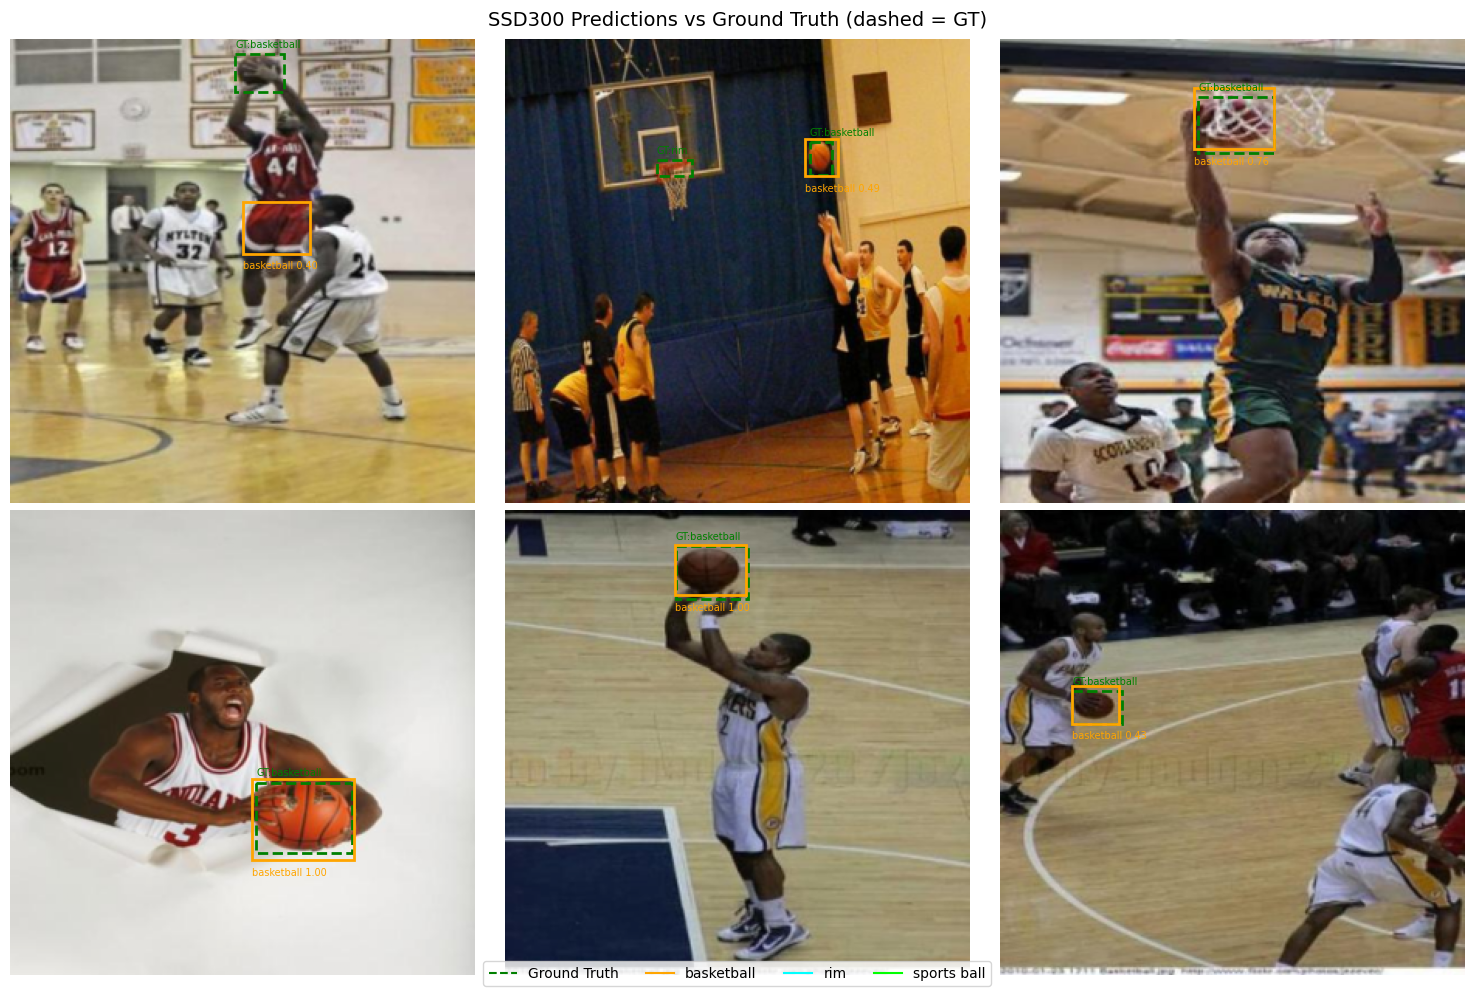

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

CLASS_NAMES = {1: "basketball", 2: "rim", 3: "sports ball"}
COLORS = {1: "orange", 2: "cyan", 3: "lime"}

def visualize_predictions(model, dataset, device, num_images=6, score_threshold=0.3):
    ''' Visualize the bounding boxes on our test set '''
    model.eval()
    indices = random.sample(range(len(dataset)), num_images)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_tensor, target = dataset[idx]
            pred = model([img_tensor.to(device)])[0]
            
            # Denormalize image for display
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            img_display = (img_tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()
            
            ax.imshow(img_display)
            
            # Draw ground truth boxes in green with dashes
            for box, label in zip(target["boxes"], target["labels"]):
                x1,y1,x2,y2 = box.tolist()
                rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor="green",
                                          facecolor="none", linestyle="--")
                ax.add_patch(rect)
                ax.text(x1, y1-4, f"GT:{CLASS_NAMES.get(label.item(),'')}",
                        color="green", fontsize=7)
            
            # Draw predicted boxes (solid, color-coded by class)
            keep = pred["scores"] >= score_threshold
            for box, label, score in zip(pred["boxes"][keep], pred["labels"][keep], pred["scores"][keep]):
                x1,y1,x2,y2 = box.cpu().tolist()
                color = COLORS.get(label.item(), "red")
                rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor=color, facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y2+10, f"{CLASS_NAMES.get(label.item(),'')} {score:.2f}",
                        color=color, fontsize=7)
            
            ax.axis("off")
    
    # Legend for each class
    from matplotlib.lines import Line2D
    legend = [Line2D([0],[0], color="green", linestyle="--", label="Ground Truth"),
              Line2D([0],[0], color="orange", label="basketball"),
              Line2D([0],[0], color="cyan",   label="rim"),
              Line2D([0],[0], color="lime",   label="sports ball")]
    fig.legend(handles=legend, loc="lower center", ncol=4, fontsize=10)
    plt.suptitle("SSD300 Predictions vs Ground Truth (dashed = GT)", fontsize=14)
    plt.tight_layout()
    plt.savefig("predictions_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()

visualize_predictions(model, test_dataset, device)

In [ ]:
import time

# Load the saved best model
model.load_state_dict(torch.load(
    "/kaggle/input/models/sarahmacgillivray/ssd300-vgg16-basketball-pth/pytorch/default/1/best_model (2).pth",
    map_location=device
))

model = model.to(device)
model.eval()

# Warm up the GPU first, first inference is always slower because of CUDA initialization
with torch.no_grad():
    warmup_imgs = [test_dataset[i][0].to(device) for i in range(4)]
    _ = model(warmup_imgs)

# Time inference over the full test set
total_time = 0
total_images = 0

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs = [img.to(device) for img in imgs]
        
        torch.cuda.synchronize()  # wait for GPU to finish before starting timer
        start = time.time()
        preds = model(imgs)
        torch.cuda.synchronize()  # wait for GPU to finish before stopping timer
        end = time.time()
        
        total_time += (end - start)
        total_images += len(imgs)

avg_ms = (total_time / total_images) * 1000
fps = total_images / total_time

print(f"Total images  : {total_images}")
print(f"Total time    : {total_time:.3f}s")
print(f"Avg per image : {avg_ms:.2f} ms")
print(f"FPS           : {fps:.1f}")

Total images  : 472 <br>
Total time    : 6.055s <br>
Avg per image : 12.83 ms <br>
FPS           : 78.0 <br>